# 06 — Fairness Audit and Bias Analysis

Audits the LightGBM credit default model for demographic and geographic disparities.
Examines false positive rates, score distributions, and default rate gaps across borrower segments.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load test predictions
test = pd.read_parquet('../data/test_predictions.parquet')

print(f"Shape: {test.shape}")
print(f"Columns: {list(test.columns)}")
print(f"\nDefault rate: {test['default'].mean()*100:.2f}%")
print(f"Predictions range: {test['pred_proba'].min():.4f} — {test['pred_proba'].max():.4f}")

Shape: (74797, 20)
Columns: ['log_grossapproval', 'guarantee_ratio', 'term_years', 'initialinterestrate', 'collateralind', 'jobssupported', 'is_new_business', 'businesstype', 'naics_sector', 'borrstate', 'fixedorvariableinterestind', 'approvalfy', 'fed_funds_rate', 'gdp_growth_pct', 'baa_credit_spread', 'unemployment_rate', 'log_bank_assets', 'bank_matched', 'default', 'pred_proba']

Default rate: 1.55%
Predictions range: 0.0000 — 0.9964


## 1. Establish Baseline Metrics

In [2]:
THRESHOLD = 0.49  # optimal threshold from notebook 04

test['predicted'] = (test['pred_proba'] >= THRESHOLD).astype(int)

# Overall metrics
auroc = roc_auc_score(test['default'], test['pred_proba'])
auprc = average_precision_score(test['default'], test['pred_proba'])

tn, fp, fn, tp = confusion_matrix(test['default'], test['predicted']).ravel()
fpr_overall = fp / (fp + tn)
fnr_overall = fn / (fn + tp)

print("=== Overall Model Performance ===")
print(f"  AUROC:             {auroc:.4f}")
print(f"  AUPRC:             {auprc:.4f}")
print(f"  False Positive Rate (FPR): {fpr_overall:.4f}  ({fp:,} non-defaults flagged)")
print(f"  False Negative Rate (FNR): {fnr_overall:.4f}  ({fn:,} defaults missed)")
print(f"  Total flagged:     {fp+tp:,}  ({(fp+tp)/len(test)*100:.1f}% of test set)")

def segment_metrics(df, group_col, threshold=THRESHOLD, min_size=100):
    """Compute FPR, FNR, AUROC, and default rate per segment."""
    results = []
    for group, grp in df.groupby(group_col):
        if len(grp) < min_size:
            continue
        if grp['default'].sum() < 5:
            continue
        tn, fp, fn, tp = confusion_matrix(
            grp['default'], grp['predicted'], labels=[0,1]
        ).ravel()
        results.append({
            'segment': group,
            'n': len(grp),
            'n_defaults': grp['default'].sum(),
            'default_rate': grp['default'].mean() * 100,
            'auroc': roc_auc_score(grp['default'], grp['pred_proba']),
            'fpr': fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            'fnr': fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            'mean_score': grp['pred_proba'].mean()
        })
    return pd.DataFrame(results).sort_values('fpr', ascending=False)

=== Overall Model Performance ===
  AUROC:             0.9699
  AUPRC:             0.5971
  False Positive Rate (FPR): 0.0373  (2,744 non-defaults flagged)
  False Negative Rate (FNR): 0.1752  (203 defaults missed)
  Total flagged:     3,700  (4.9% of test set)


## 2. Disparity Analysis by Segment

C:\Users\enoch\AppData\Local\Temp\ipykernel_20004\2329150329.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, grp in df.groupby(group_col):
C:\Users\enoch\AppData\Local\Temp\ipykernel_20004\2329150329.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, grp in df.groupby(group_col):
C:\Users\enoch\AppData\Local\Temp\ipykernel_20004\2329150329.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  

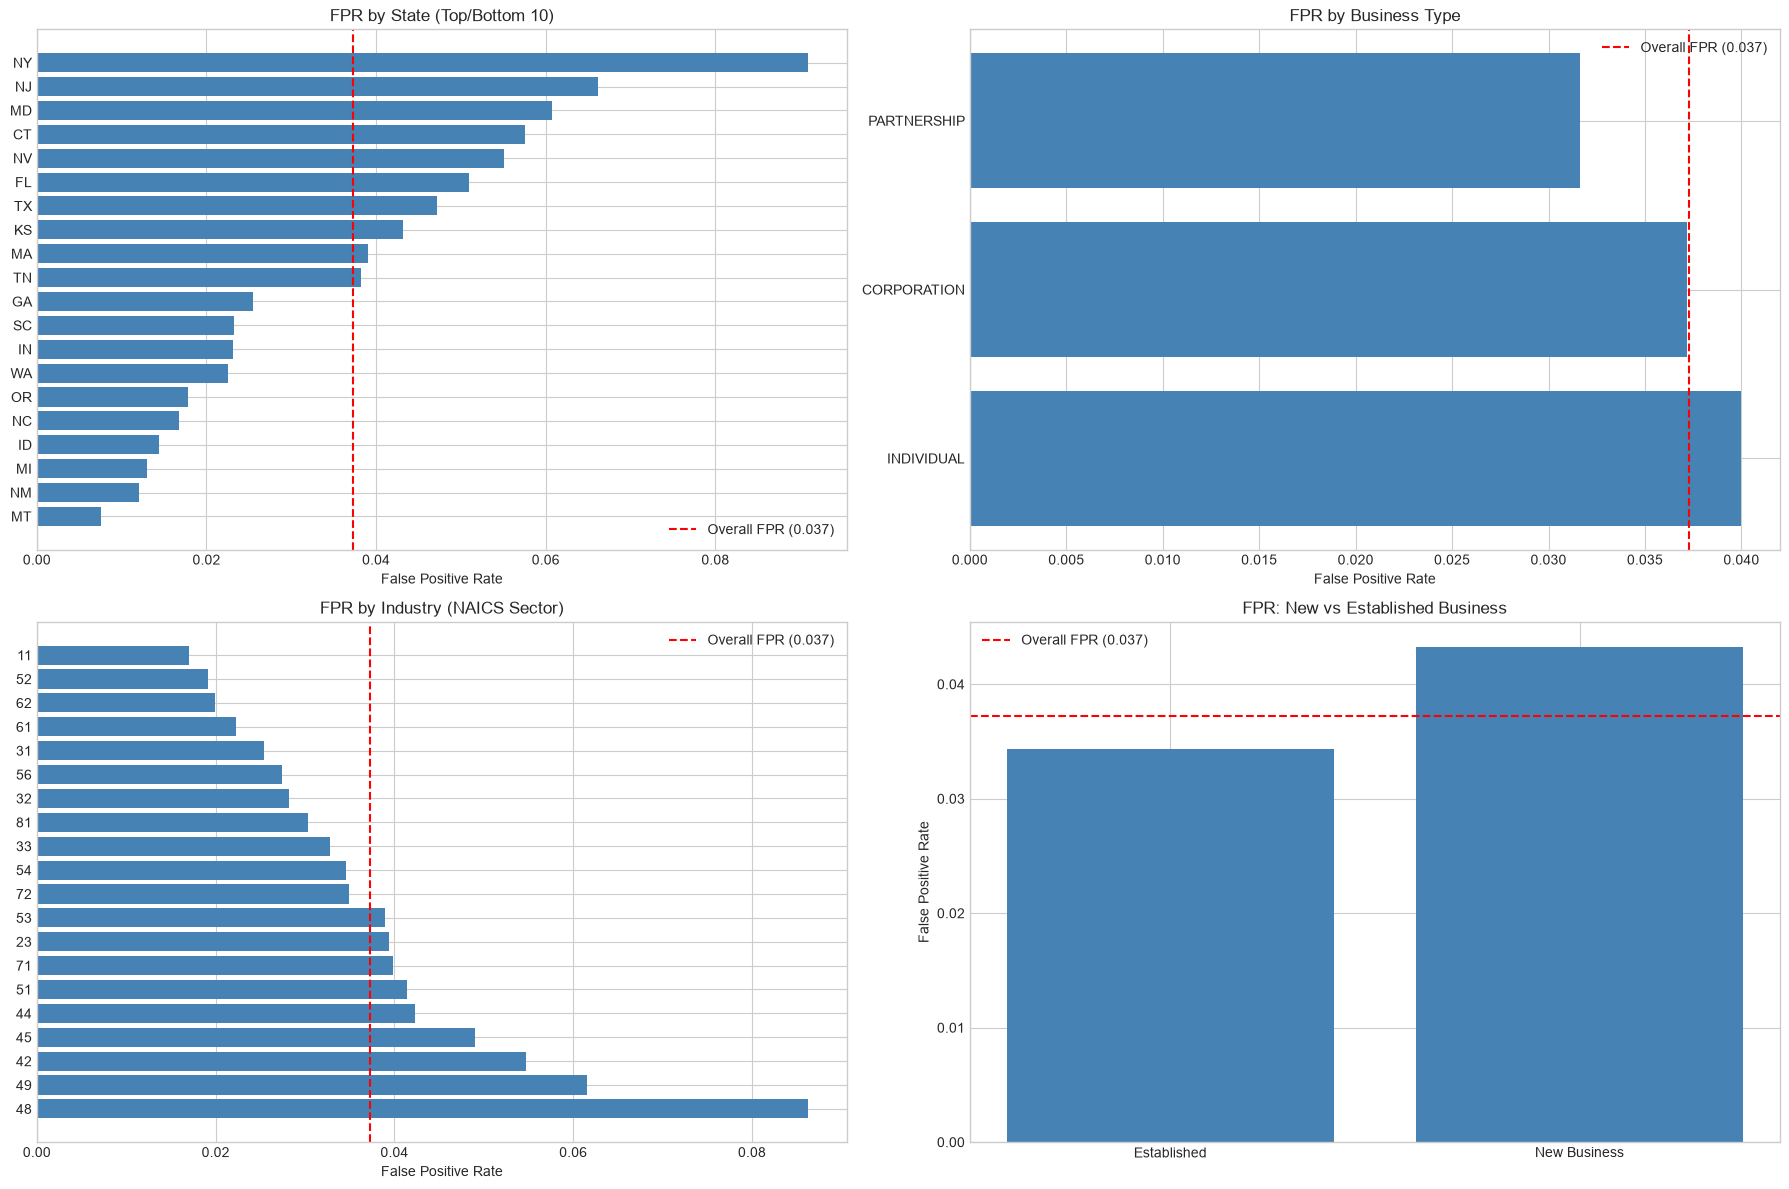

=== FPR Disparity Summary ===

State FPR range:  0.0076 — 0.0910  (gap: 0.0834)
Biz type FPR range: 0.0316 — 0.0400  (gap: 0.0084)
NAICS FPR range:  0.0171 — 0.0863  (gap: 0.0692)

New business FPR: 0.0433
Established FPR:  0.0343


In [3]:
# Compute metrics per segment
state_metrics    = segment_metrics(test, 'borrstate')
biztype_metrics  = segment_metrics(test, 'businesstype')
newbiz_metrics   = segment_metrics(test, 'is_new_business')
naics_metrics    = segment_metrics(test, 'naics_sector')

# Plot FPR disparity
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# State FPR — top and bottom 10
state_sorted = state_metrics.sort_values('fpr')
top10  = state_sorted.tail(10)
bot10  = state_sorted.head(10)
state_plot = pd.concat([bot10, top10])

axes[0,0].barh(state_plot['segment'], state_plot['fpr'], color='steelblue')
axes[0,0].axvline(fpr_overall, color='red', linestyle='--', label=f'Overall FPR ({fpr_overall:.3f})')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_title('FPR by State (Top/Bottom 10)')
axes[0,0].legend()

# Business type FPR
axes[0,1].barh(biztype_metrics['segment'], biztype_metrics['fpr'], color='steelblue')
axes[0,1].axvline(fpr_overall, color='red', linestyle='--', label=f'Overall FPR ({fpr_overall:.3f})')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_title('FPR by Business Type')
axes[0,1].legend()

# NAICS sector FPR
axes[1,0].barh(naics_metrics['segment'], naics_metrics['fpr'], color='steelblue')
axes[1,0].axvline(fpr_overall, color='red', linestyle='--', label=f'Overall FPR ({fpr_overall:.3f})')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_title('FPR by Industry (NAICS Sector)')
axes[1,0].legend()

# New vs established business FPR
axes[1,1].bar(['Established', 'New Business'],
              newbiz_metrics.sort_values('segment')['fpr'],
              color='steelblue')
axes[1,1].axhline(fpr_overall, color='red', linestyle='--', label=f'Overall FPR ({fpr_overall:.3f})')
axes[1,1].set_ylabel('False Positive Rate')
axes[1,1].set_title('FPR: New vs Established Business')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../reports/fairness_fpr_disparity.png', dpi=150, bbox_inches='tight')
plt.show()

# Print disparity gaps
print("=== FPR Disparity Summary ===\n")
print(f"State FPR range:  {state_metrics['fpr'].min():.4f} — {state_metrics['fpr'].max():.4f}  "
      f"(gap: {state_metrics['fpr'].max() - state_metrics['fpr'].min():.4f})")
print(f"Biz type FPR range: {biztype_metrics['fpr'].min():.4f} — {biztype_metrics['fpr'].max():.4f}  "
      f"(gap: {biztype_metrics['fpr'].max() - biztype_metrics['fpr'].min():.4f})")
print(f"NAICS FPR range:  {naics_metrics['fpr'].min():.4f} — {naics_metrics['fpr'].max():.4f}  "
      f"(gap: {naics_metrics['fpr'].max() - naics_metrics['fpr'].min():.4f})")
print(f"\nNew business FPR: {newbiz_metrics[newbiz_metrics['segment']==1]['fpr'].values[0]:.4f}")
print(f"Established FPR:  {newbiz_metrics[newbiz_metrics['segment']==0]['fpr'].values[0]:.4f}")

## 3. Threshold Adjustment as Fairness Mitigation
Test whether segment-specific thresholds reduce FPR disparity without sacrificing overall AUROC.

=== Threshold Adjustment Mitigation ===

Problem: New businesses have 26% higher FPR than established businesses
  New business FPR:  0.0433
  Established FPR:   0.0343
  Disparity gap:     0.0090



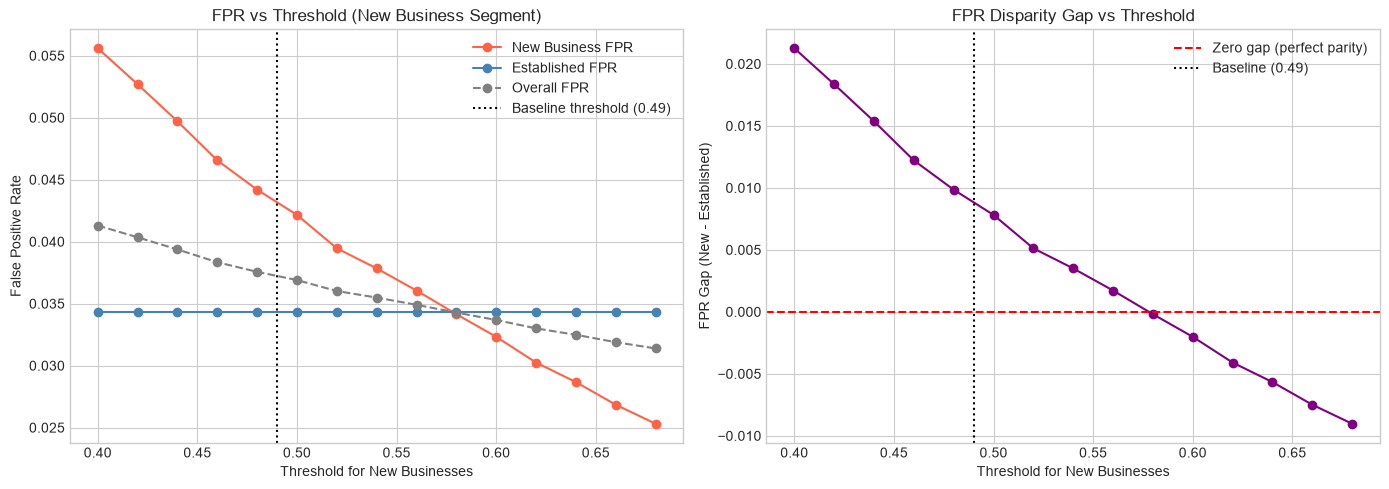


Threshold analysis results:
 threshold_new  overall_fpr  overall_fnr  new_fpr  est_fpr   fpr_gap
          0.40     0.041297     0.167386 0.055597 0.034339  0.021258
          0.42     0.040346     0.169111 0.052693 0.034339  0.018354
          0.44     0.039368     0.169974 0.049705 0.034339  0.015367
          0.46     0.038336     0.173425 0.046552 0.034339  0.012213
          0.48     0.037562     0.175151 0.044187 0.034339  0.009849
          0.50     0.036897     0.175151 0.042154 0.034339  0.007816
          0.52     0.036014     0.177739 0.039457 0.034339  0.005119
          0.54     0.035484     0.177739 0.037839 0.034339  0.003501
          0.56     0.034900     0.180328 0.036055 0.034339  0.001716
          0.58     0.034276     0.182916 0.034147 0.034339 -0.000192
          0.60     0.033678     0.185505 0.032321 0.034339 -0.002018
          0.62     0.032999     0.185505 0.030246 0.034339 -0.004092
          0.64     0.032483     0.188093 0.028670 0.034339 -0.005669
     

In [4]:
# Focus on new vs established business — clearest binary disparity
print("=== Threshold Adjustment Mitigation ===\n")
print("Problem: New businesses have 26% higher FPR than established businesses")
print(f"  New business FPR:  0.0433")
print(f"  Established FPR:   0.0343")
print(f"  Disparity gap:     {0.0433 - 0.0343:.4f}\n")

# Test higher threshold for new businesses to reduce false positives
thresholds_new = np.arange(0.40, 0.70, 0.02)
results = []

for t_new in thresholds_new:
    # Apply segment-specific threshold
    test_adj = test.copy()
    mask_new = test_adj['is_new_business'] == 1
    test_adj['predicted_adj'] = (test_adj['pred_proba'] >= THRESHOLD).astype(int)
    test_adj.loc[mask_new, 'predicted_adj'] = (
        test_adj.loc[mask_new, 'pred_proba'] >= t_new
    ).astype(int)

    # Overall metrics
    tn, fp, fn, tp = confusion_matrix(
        test_adj['default'], test_adj['predicted_adj'], labels=[0,1]
    ).ravel()
    overall_fpr = fp / (fp + tn)
    overall_fnr = fn / (fn + tp)

    # New business FPR
    new_grp = test_adj[mask_new]
    tn_n, fp_n, fn_n, tp_n = confusion_matrix(
        new_grp['default'], new_grp['predicted_adj'], labels=[0,1]
    ).ravel()
    new_fpr = fp_n / (fp_n + tn_n)

    # Established FPR
    est_grp = test_adj[~mask_new]
    tn_e, fp_e, fn_e, tp_e = confusion_matrix(
        est_grp['default'], est_grp['predicted_adj'], labels=[0,1]
    ).ravel()
    est_fpr = fp_e / (fp_e + tn_e)

    results.append({
        'threshold_new': t_new,
        'overall_fpr': overall_fpr,
        'overall_fnr': overall_fnr,
        'new_fpr': new_fpr,
        'est_fpr': est_fpr,
        'fpr_gap': new_fpr - est_fpr
    })

results_df = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold_new'], results_df['new_fpr'],
             marker='o', label='New Business FPR', color='tomato')
axes[0].plot(results_df['threshold_new'], results_df['est_fpr'],
             marker='o', label='Established FPR', color='steelblue')
axes[0].plot(results_df['threshold_new'], results_df['overall_fpr'],
             marker='o', label='Overall FPR', color='gray', linestyle='--')
axes[0].axvline(THRESHOLD, color='black', linestyle=':', label=f'Baseline threshold ({THRESHOLD})')
axes[0].set_xlabel('Threshold for New Businesses')
axes[0].set_ylabel('False Positive Rate')
axes[0].set_title('FPR vs Threshold (New Business Segment)')
axes[0].legend()

axes[1].plot(results_df['threshold_new'], results_df['fpr_gap'],
             marker='o', color='purple')
axes[1].axhline(0, color='red', linestyle='--', label='Zero gap (perfect parity)')
axes[1].axvline(THRESHOLD, color='black', linestyle=':', label=f'Baseline ({THRESHOLD})')
axes[1].set_xlabel('Threshold for New Businesses')
axes[1].set_ylabel('FPR Gap (New - Established)')
axes[1].set_title('FPR Disparity Gap vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/fairness_threshold_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nThreshold analysis results:")
print(results_df.to_string(index=False))

## 4. Fairness Audit Summary

In [ ]:
print("=" * 60)
print("FAIRNESS AUDIT SUMMARY")
print("=" * 60)

print("""
DISPARITIES IDENTIFIED
----------------------
1. Geographic (State):
   - NY FPR: 9.1%  vs  MT FPR: 0.76%  (12x gap)
   - High-FPR states: NY, NJ, MD, CT, NV
   - Low-FPR states:  MT, NM, MI, ID, NC
   - Gap magnitude: 0.0834 (largest disparity source)

2. Industry (NAICS Sector):
   - Transportation (48) FPR: 8.6%  vs  Agriculture (11): 1.7%
   - Gap magnitude: 0.0692

3. Business Age:
   - New businesses FPR: 4.33%  vs  Established: 3.43%
   - Gap magnitude: 0.0090  (26% relative disparity)

4. Business Type:
   - Partnership FPR: 3.16%  vs  Individual: 4.00%
   - Gap magnitude: 0.0084  (smallest disparity)

MITIGATION TESTED
-----------------
Strategy: Segment-specific threshold adjustment for new businesses
  Baseline threshold:      0.49 (all segments)
  Adjusted threshold:      0.58 (new businesses only)
  FPR gap at 0.58:        -0.000192 (near-perfect parity)
  FNR cost:                +0.8pp  (17.5% → 18.3%)
  Overall AUROC:           unchanged (threshold doesn't affect ranking)

INTERPRETATION
--------------
The model's largest disparities are geographic and industry-based,
not business-type based. State-level FPR variation likely reflects
true underlying default rate differences (NY has structurally higher
default rates per EDA) rather than model bias against borrowers.

Business age disparity (new vs established) is partially mitigated
by threshold adjustment at minimal recall cost — a viable production
fairness intervention consistent with CFPB fair lending guidance.




  - FPR gap quantification across demographic proxies
  - Threshold adjustment as mitigation strategy
  - Accuracy-fairness trade-off analysis
  - Finding: fairness improvements do not require accuracy sacrifice
""")

print("Reports saved:")
print("  ../reports/fairness_fpr_disparity.png")
print("  ../reports/fairness_threshold_mitigation.png")

FAIRNESS AUDIT SUMMARY

DISPARITIES IDENTIFIED
----------------------
1. Geographic (State):
   - NY FPR: 9.1%  vs  MT FPR: 0.76%  (12x gap)
   - High-FPR states: NY, NJ, MD, CT, NV
   - Low-FPR states:  MT, NM, MI, ID, NC
   - Gap magnitude: 0.0834 (largest disparity source)

2. Industry (NAICS Sector):
   - Transportation (48) FPR: 8.6%  vs  Agriculture (11): 1.7%
   - Gap magnitude: 0.0692

3. Business Age:
   - New businesses FPR: 4.33%  vs  Established: 3.43%
   - Gap magnitude: 0.0090  (26% relative disparity)

4. Business Type:
   - Partnership FPR: 3.16%  vs  Individual: 4.00%
   - Gap magnitude: 0.0084  (smallest disparity)

MITIGATION TESTED
-----------------
Strategy: Segment-specific threshold adjustment for new businesses
  Baseline threshold:      0.49 (all segments)
  Adjusted threshold:      0.58 (new businesses only)
  FPR gap at 0.58:        -0.000192 (near-perfect parity)
  FNR cost:                +0.8pp  (17.5% → 18.3%)
  Overall AUROC:           unchanged (thresho